In [1]:
import numpy as np
import matplotlib.pyplot as plt
from dataclasses import dataclass
from dataclasses import field
from copy import copy
import math
import random
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
from matplotlib.colors import ListedColormap

In [ ]:
@dataclass
class prey:
    location: int
    eaten: bool = False
    escaped: bool = False
    cooperative: bool = False

    def __str__(self):
        return (
            f"prey(\n"
            f"  location={self.location},\n"
            f"  eaten={self.eaten},\n"
            f"  escaped={self.escaped},\n"
            f"  cooperative={self.cooperative}\n"
            f")"
        )


@dataclass
class predator:
    location: int
    hunting: bool = False

    def __str__(self):
        return (
            f"predator(\n"
            f"  location={self.location},\n"
            f"  hunting={self.hunting}\n"
            f")"
        )

In [127]:
#environment will be created, initializing two prey fish and one predator.

def locations_to_list(locations, fish_type):
    """
    A function that takes a list of locations, and returns a list of fish
    at the specified locations.
    
    Parameters: 
    ------
    locations: list of ints representing the locations of the fish
    fish_type: string, either 'prey' or 'predator', indicating the type of fish
    
    Returns:
    ------
    fish_list: list of fish objects with the given locations.
    """
    
    fish_list = []
    for loc in locations:
        if fish_type == 'prey':
            my_fish = prey(location = loc)
        elif fish_type == 'predator':
            my_fish = predator(location = loc)

        fish_list.append(my_fish)
    
    return fish_list

def get_locations(prey1, prey2, pred):
    """
    Returns a NumPy array containing the locations of:
    [prey1, prey2, predator]

    If a prey has escaped, its location is set to -1.
    """

    #this is a grid of size 3x2, where the first column contains the locations of the 
    #prey and predator, and the second column contains the status of the prey 
    #(0 for alive, 2 for escaped/eaten).
    
    grid = np.zeros((3,2), dtype=int)

    if (not prey1.escaped) and (not prey1.eaten) :
        grid[0][0] = prey1.location
    elif prey1.eaten:
        grid[0][1] = 2
    if (not prey2.escaped) and (not prey2.eaten):
        grid[1][0] = prey2.location
    elif prey2.eaten:
        grid[1][1] = 2

    grid[2][0] = pred.location

    return grid

def fish_move(prey1, prey2, predator1, p):
    success = False

    prey1gone = prey1.escaped 
    prey2gone = prey2.escaped
    if not (prey1gone or prey2gone):
        success = decision_step(prey1, prey2, predator1, p)
    elif prey1gone:
        success = one_fish_step(prey2, predator1)
    elif prey2gone:
        success = one_fish_step(prey1, predator1)
    else:
        print("error1")
    return success

def one_fish_step(gprey, predator1):
    predator1.location -= 1
    if predator1.location > 50:
        predator1.location = 49
    elif predator1.location < 0:
        predator1.location = 0
    gprey.location -= 1
    if gprey.location < 0:
        gprey.escaped = True
        return True
    else:
        return False

def decision_step(prey1, prey2, predator1, p):
    """
    A function that simulates a single time-step where each prey fish makes
    a decision to cooperate or abandon their fellow fish.

    Parameters:
    ------
    prey1: a prey fish object
    prey2: a prey fish object
    predator: a predator object
    
    """

    #predator makes a random choice to move left, right, or stay in place.
    predator1.location -= 1
    #random.choice(pred_decision)
    # check if the predator has moved out of bounds
    if predator1.location > 50:
        predator1.location = 49
    elif predator1.location < 0:
        predator1.location = 0
    
    #Prey move
    decisions = ['cooperate', 'flee']
    pred_decision = [-1, 0, 1]
    #check the decisions made by either fish.
    #if both fish cooperate, they move one step away
    #if they both flee, they remain in place
    #if one cooperates and the other flees, the one that flees moves two steps away.
    decision_made = []
    for i in range(2):
        decision = np.random.choice(decisions, p=p)
        decision_made.append(decision)
    
    if decision_made[0] == decision_made[1] == 'cooperate':
        #both fish move one step away
        prey1.location -= 1
        prey2.location -= 1
        #print("cooperate")
    elif decision_made[0] == 'cooperate' and decision_made[1] == 'flee':
        #the fleeing fish moves two steps away
        prey1.location -=2
        #print("non-cooperation")
    elif decision_made[0] == 'flee' and decision_made[1] == 'cooperate':
        #the fleeing fish moves two steps away
        prey2.location -= 2
        #print("non-cooperation")
    
    # check if the prey have escaped
    if prey1.location < 0:
        prey1.escaped = True
    if prey2.location < 0:
        prey2.escaped = True
        
    success = prey1.escaped and  prey2.escaped   
    return success


def eat(prey1, prey2, predator1):
    """
    A function that simulates a hunting step, where the predator can hunt its
    prey depending on its distance to the prey fish.

    Parameters:
    ------
    prey_list: list of prey fish objects
    predator: a predator object

    Returns:
    ------
    prey_list: list of prey fish objects with updated eaten status
    predator: updated predator object
    """
    twofish = True
    probability1 = 0
    probability2 = 0
    
    distance1 = np.abs(prey1.location - predator1.location)
    if distance1 < 10:
        probability1 = 1 - distance1/10
        
    distance2 = np.abs(prey2.location - predator1.location)
    if distance2 < 10:
        probability2 = 1 - distance2/10
    
    r = np.random.random()
    if r < probability1:
        prey1.eaten = True
        twofish = False
    if r < probability2:
        prey2.eaten = True
        twofish = False
                
    return not twofish


#changing.

In [128]:
def run1dSimulation(p):
    """
    The "main" function that run the 1d simulation
    
    input:
    T timestep in integer

    Return:
    LISTS: a array of lists at each timestep
    """
    grids = []
    prey1 = prey(25)
    prey2 = prey(25)
    predator1 = predator(49)
    
    grid = get_locations(prey1, prey2, predator1)
    grids.append(grid)
    T = 0
    
    fail = False
    #add the fish of fish_type at locations to fishlist
    
    while not fail:
        success = fish_move(prey1, prey2, predator1, p) #the new fish list after this time step
        T+=1
        if success:
            grid = get_locations(prey1, prey2, predator1)
            grids.append(grid)
            
            return grids,T, True
        fail = eat(prey1, prey2, predator1) 
        grid = get_locations(prey1, prey2, predator1)
        grids.append(grid)
    
    return grids, T, False

In [129]:
def visualize(grids):
    for grid in grids:
        line = ""
        print(grid)
        for i in range(50):
            if i == grid[0][0]:
                line += "X" if grid[1][1] == 2 else "■"
            if i == grid[1][0]:
                line += "X" if grid[0][1] == 2 else "■"
            elif i == grid[2][0]:
                line += "●"
            else:
                line += "☐"

        print(line)

In [130]:
Ts1_success = [] #stochastic
Ts1_fail = []
sim_1_success = 0
sim_1_rates = []
for i in range(1000):
    grids, T, success = run1dSimulation(p=[0.5, 0.5])
    if success:
        Ts1_success.append(T)
        sim_1_success += 1
    else:
        Ts1_fail.append(T)
    
    sim_1_rates.append(sim_1_success/(i+1))

Ts2_success = [] #non cooperative
Ts2_fail = []
sim_2_success = 0
sim_2_rates = []

for i in range(1000):
    grids, T, success = run1dSimulation(p=[0.33, 0.67])
    if success:
        Ts2_success.append(T)
        sim_2_success += 1
    else:
        Ts2_fail.append(T)
    
    sim_2_rates.append(sim_2_success/(i+1))

Ts3_success = [] #cooperative
Ts3_fail = []
sim_3_success = 0
sim_3_rates = []

for i in range(1000):
    grids, T, success = run1dSimulation(p=[0.67, 0.33])
    if success:
        Ts3_success.append(T)
        sim_3_success += 1
    else:
        Ts3_fail.append(T)

    sim_3_rates.append(sim_3_success/(i+1))

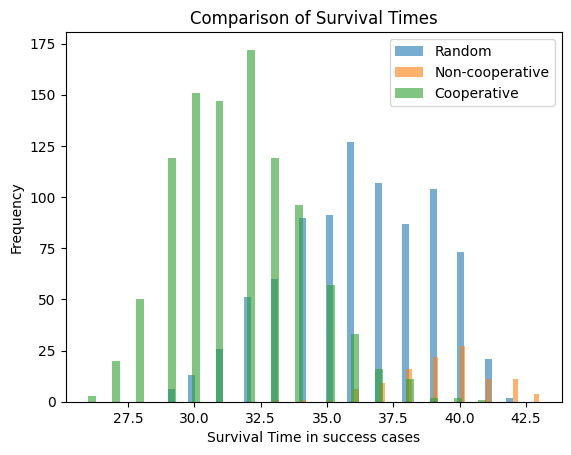

In [131]:
plt.hist(Ts1_success, bins=50, alpha=0.6, label='Random')
plt.hist(Ts2_success, bins=50, alpha=0.6, label='Non-cooperative')
plt.hist(Ts3_success, bins=50, alpha=0.6, label='Cooperative')

plt.xlabel("Survival Time in success cases")
plt.ylabel("Frequency")
plt.title("Comparison of Survival Times")
plt.legend()

plt.show()

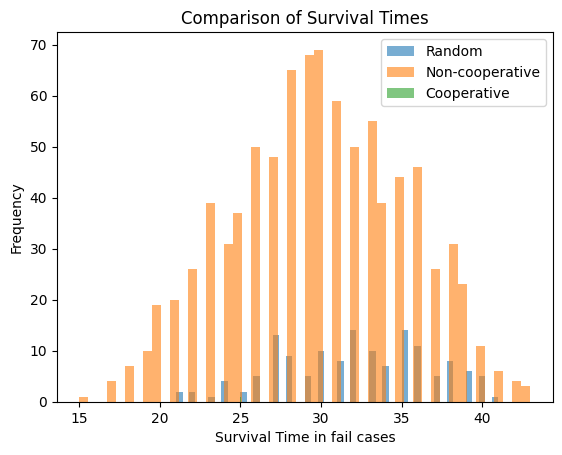

In [132]:
plt.hist(Ts1_fail, bins=50, alpha=0.6, label='Random')
plt.hist(Ts2_fail, bins=50, alpha=0.6, label='Non-cooperative')
plt.hist(Ts3_fail, bins=50, alpha=0.6, label='Cooperative')

plt.xlabel("Survival Time in fail cases")
plt.ylabel("Frequency")
plt.title("Comparison of Survival Times")
plt.legend()

plt.show()

Now, let's plot the success rates for each simulation.

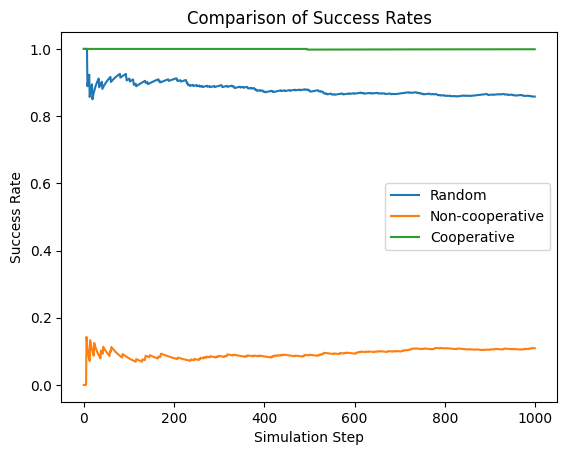

In [133]:
plt.plot(sim_1_rates, label='Random')
plt.plot(sim_2_rates, label='Non-cooperative')
plt.plot(sim_3_rates, label='Cooperative')

plt.xlabel("Simulation Step")
plt.ylabel("Success Rate")
plt.title("Comparison of Success Rates")
plt.legend()

plt.show()

In [134]:
def AnimateMeSmooth(grids):

    scale = 3
    visual_size = 50 * scale

    def get_pos(grid):
        return np.array([
            grid[0][0] * scale,
            grid[1][0] * scale,
            grid[2][0] * scale
        ], dtype=int)

    smooth_frames = []

    for i in range(len(grids) - 1):

        start_grid = grids[i]
        end_grid = grids[i + 1]

        start_pos = get_pos(start_grid)
        end_pos = get_pos(end_grid)

        for s in range(scale):

            frac = s / scale

            pos = start_pos + np.round(
                frac * (end_pos - start_pos)
            ).astype(int)

            smooth_frames.append((pos, end_grid))

    smooth_frames.append(
        (get_pos(grids[-1]), grids[-1])
    )

    def GetData(mm):

        mm = min(mm, len(smooth_frames) - 1)

        line = np.zeros(visual_size)

        pos, grid = smooth_frames[mm]

        # =========================
        # prey1
        # =========================

        prey1_loc = pos[0]

        if grid[0][1] == 2:
            # eaten -> red corpse remains
            if 0 <= prey1_loc < visual_size:
                line[prey1_loc] = 2
        else:
            if 0 <= prey1_loc < visual_size:
                line[prey1_loc] = -1

        # =========================
        # prey2
        # =========================

        prey2_loc = pos[1]

        if grid[1][1] == 2:
            if 0 <= prey2_loc < visual_size:
                line[prey2_loc] = 2
        else:
            if 0 <= prey2_loc < visual_size:
                line[prey2_loc] = -1

        # =========================
        # predator
        # =========================

        pred_loc = pos[2]

        if 0 <= pred_loc < visual_size:
            line[pred_loc] = 1

        return line.reshape(1, visual_size)

    # custom colors:
    # -1 -> blue prey
    #  0 -> white empty
    #  1 -> black predator
    #  2 -> red eaten prey

    cmap = ListedColormap([
        "blue",   # -1
        "white",  # 0
        "black",  # 1
        "red"     # 2
    ])

    fig = plt.figure(figsize=(20, 2))

    plot = plt.imshow(
        GetData(0),
        cmap=cmap,
        vmin=-1,
        vmax=2,
        aspect="auto"
    )

    plt.yticks([])

    def init():
        plot.set_data(GetData(0))
        return plot,

    def update(j):
        plot.set_array(GetData(j))
        return plot,

    anim = FuncAnimation(
        fig,
        update,
        frames=len(smooth_frames),
        init_func=init,
        interval=100,
        blit=True,
        repeat=False
    )

    plt.close()

    return anim

In [16]:
grids, T, success = run1dSimulation(p=[0.2, 0.8])
print(success)
anim = AnimateMeSmooth(grids)
HTML(anim.to_jshtml())

False


In [135]:
def AnimateMeScatter(grids):
    scale = 3
    visual_size = 50 * scale

    def get_pos(grid):
        return np.array([
            grid[0][0] * scale,
            grid[1][0] * scale,
            grid[2][0] * scale
        ], dtype=float)

    smooth_frames = []

    for i in range(len(grids) - 1):
        start_pos = get_pos(grids[i])
        end_pos = get_pos(grids[i + 1])

        for s in range(scale):
            frac = s / scale
            pos = start_pos + frac * (end_pos - start_pos)
            smooth_frames.append((pos, grids[i + 1]))

    smooth_frames.append((get_pos(grids[-1]), grids[-1]))

    fig, ax = plt.subplots(figsize=(20, 2))

    ax.set_xlim(-1, visual_size)
    ax.set_ylim(-1, 1)
    ax.set_yticks([])
    ax.set_xlabel("Position")
    ax.grid(True)

    prey_scatter = ax.scatter([], [], marker="<", s=300, label="prey")
    pred_scatter = ax.scatter([], [], marker="X", s=400, label="predator")
    eaten_scatter = ax.scatter([], [], marker="x", s=300, label="eaten")

    ax.legend(loc="upper right")

    def update(j):
        pos, grid = smooth_frames[j]

        prey_x = []
        prey_y = []

        eaten_x = []
        eaten_y = []

        # prey1
        if grid[0][1] == 2:
            eaten_x.append(pos[0])
            eaten_y.append(0)
        else:
            prey_x.append(pos[0])
            prey_y.append(0)

        # prey2
        if grid[1][1] == 2:
            eaten_x.append(pos[1])
            eaten_y.append(0)
        else:
            prey_x.append(pos[1])
            prey_y.append(0)

        pred_x = [pos[2]]
        pred_y = [0]

        prey_scatter.set_offsets(np.column_stack([prey_x, prey_y]))
        pred_scatter.set_offsets(np.column_stack([pred_x, pred_y]))
        eaten_scatter.set_offsets(np.column_stack([eaten_x, eaten_y]))

        return prey_scatter, pred_scatter, eaten_scatter

    anim = FuncAnimation(
        fig,
        update,
        frames=len(smooth_frames),
        interval=100,
        blit=True,
        repeat=False
    )

    plt.close()
    return anim

In [23]:
grids, T, success = run1dSimulation(p=[0.33, 0.67])
print(success)
anim = AnimateMeScatter(grids)
HTML(anim.to_jshtml())

False


In [110]:
def decision_step_tft(prey1, prey2, predator1, prev_decision):
    """
    A function that simulates a single time-step for the ecosystem; each prey fish copies the
    other fish's previous decision to cooperate or flee. The reward matrix remains the same.
    """
    predator1.location -= 1
    if predator1.location > 50:
        predator1.location = 49
    elif predator1.location < 0:
        predator1.location = 0

    decision_made = []
                
    if prev_decision is None:
        for i in range(2):
            decision_made.append(np.random.choice(['c', 'f']))
    else:
        decision_made = prev_decision
    
    if decision_made[0] == decision_made[1] == 'c':
        prey1.location -= 1
        prey2.location -= 1
    elif decision_made[0] == 'c' and decision_made[1] == 'f':
        prey1.location -= 2
    elif decision_made[0] == 'f' and decision_made[1] == 'c':
        prey2.location -= 2

    if prey1.location < 0:
        prey1.escaped = True
    if prey2.location < 0:
        prey2.escaped = True

    success = prey1.escaped and prey2.escaped
    return success, decision_made


def fish_move_tft(prey1, prey2, predator1, prev_decision):
    success = False

    prey1gone = prey1.escaped 
    prey2gone = prey2.escaped
    if not (prey1gone or prey2gone):
        success, decision_made = decision_step_tft(prey1, prey2, predator1, prev_decision)
        return success, decision_made
    elif prey1gone:
        success = one_fish_step(prey2, predator1)
    elif prey2gone:
        success = one_fish_step(prey1, predator1)
    else:
        print("error1")
    return success, None

In [111]:
def run1dSimulation_tft(prev_decision):
    """
    Tit-For-Tat 1-Dimensional Simulation. Uses the tit-for-tat decision making function to compute
    a single timestep of the simulation.
    
    Returns:
    grids (list): A list of grids representing the state of the simulation at each timestep.
    T (int): The number of timesteps taken.
    A boolean that indicates whether both fish have survived the dilemma.
    """
    grids = []
    prey1 = prey(25)
    prey2 = prey(25)
    predator1 = predator(49)
    
    grid = get_locations(prey1, prey2, predator1)
    grids.append(grid)
    T = 0
    
    fail = False
    #add the fish of fish_type at locations to fishlist
    
    while not fail:
        success, decision_made = fish_move_tft(prey1, prey2, predator1, prev_decision) 
        T+=1
        if success:
            grid = get_locations(prey1, prey2, predator1)
            grids.append(grid)
            
            return grids,T, True, decision_made
        fail = eat(prey1, prey2, predator1) 
        grid = get_locations(prey1, prey2, predator1)
        grids.append(grid)
    
    return grids, T, False, decision_made

In [116]:
decision_passed = None
Ts_tft_success = []
Ts_tft_fail = []
tft_success = 0
tft_rates = []

for i in range(1000):
    grids, T, success, decision_made = run1dSimulation_tft(decision_passed)
    decision_passed = decision_made
    if success:
        Ts_tft_success.append(T)
        tft_success += 1
    else:
        Ts_tft_fail.append(T)
    tft_rates.append(tft_success/(i+1))
    
    

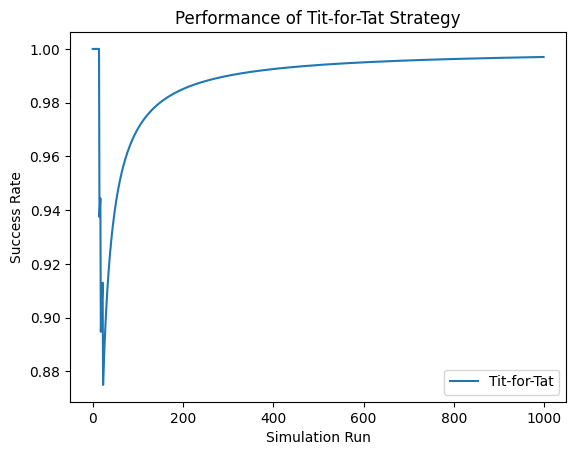

In [119]:
plt.plot(tft_rates, label='Tit-for-Tat')
plt.xlabel("Simulation Run")
plt.ylabel("Success Rate")
plt.title("Performance of Tit-for-Tat Strategy")
plt.legend()
plt.show()